Hey guys please find my try on iris dataset it is might not be perfect but it's showing all inside of Data. I take some reference from other notebooks in other to make for this.

Please so support if you like it.

Thnaks in Advance. 

In [1]:
import numpy as np 
import pandas as pd 
import os
import cufflinks as cf
cf.set_config_file(offline=True)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from xgboost import XGBClassifier
from vecstack import stacking
import seaborn as sns
import matplotlib.pyplot as plt
!pip install sweetviz
import sweetviz as sv


     |████████████████████████████████| 325 kB 403 kB/s 


In [2]:
df = pd.read_csv("../input/iris/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris_report = sv.analyze(df)
iris_report.show_html('iris.html')

:FEATURES DONE:                    |█████████████████████| [100%]   00:02  -> (00:00 left)
:PAIRWISE DONE:                    |█████████████████████| [100%]   00:00  -> (00:00 left)


Creating Associations graph... DONE!
Report iris.html was generated! NOTEBOOK/COLAB USERS: no browser will pop up, the report is saved in your notebook/colab files.


In [4]:
#!ls
#!conda install dtale -c conda-forge -y
#!pip install flask_ngrok
#!pip install plotly
#!pip install cufflinks

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.groupby(by='Species').describe().T

Species              Iris-setosa  Iris-versicolor  Iris-virginica
Id            count    50.000000        50.000000       50.000000
              mean     25.500000        75.500000      125.500000
              std      14.577380        14.577380       14.577380
              min       1.000000        51.000000      101.000000
              25%      13.250000        63.250000      113.250000
              50%      25.500000        75.500000      125.500000
              75%      37.750000        87.750000      137.750000
              max      50.000000       100.000000      150.000000
SepalLengthCm count    50.000000        50.000000       50.000000
              mean      5.006000         5.936000        6.588000
              std       0.352490         0.516171        0.635880
              min       4.300000         4.900000        4.900000
              25%       4.800000         5.600000        6.225000
              50%       5.000000         5.900000        6.500000
              75%       5.200000         6.300000        6.900000
              max       5.800000         7.000000        7.900000
SepalWidthCm  count    50.000000        50.000000       50.000000
              mean      3.418000         2.770000        2.974000
              std       0.381024         0.313798        0.322497
              min       2.300000         2.000000        2.200000
              25%       3.125000         2.525000        2.800000
              50%       3.400000         2.800000        3.000000
              75%       3.675000         3.000000        3.175000
              max       4.400000         3.400000        3.800000
PetalLengthCm count    50.000000        50.000000       50.000000
              mean      1.464000         4.260000        5.552000
              std       0.173511         0.469911        0.551895
              min       1.000000         3.000000        4.500000
              25%       1.400000         4.000000        5.100000
              50%       1.500000         4.350000        5.550000
              75%       1.575000         4.600000        5.875000
              max       1.900000         5.100000        6.900000
PetalWidthCm  count    50.000000        50.000000       50.000000
              mean      0.244000         1.326000        2.026000
              std       0.107210         0.197753        0.274650
              min       0.100000         1.000000        1.400000
              25%       0.200000         1.200000        1.800000
              50%       0.200000         1.300000        2.000000
              75%       0.300000         1.500000        2.300000
              max       0.600000         1.800000        2.500000

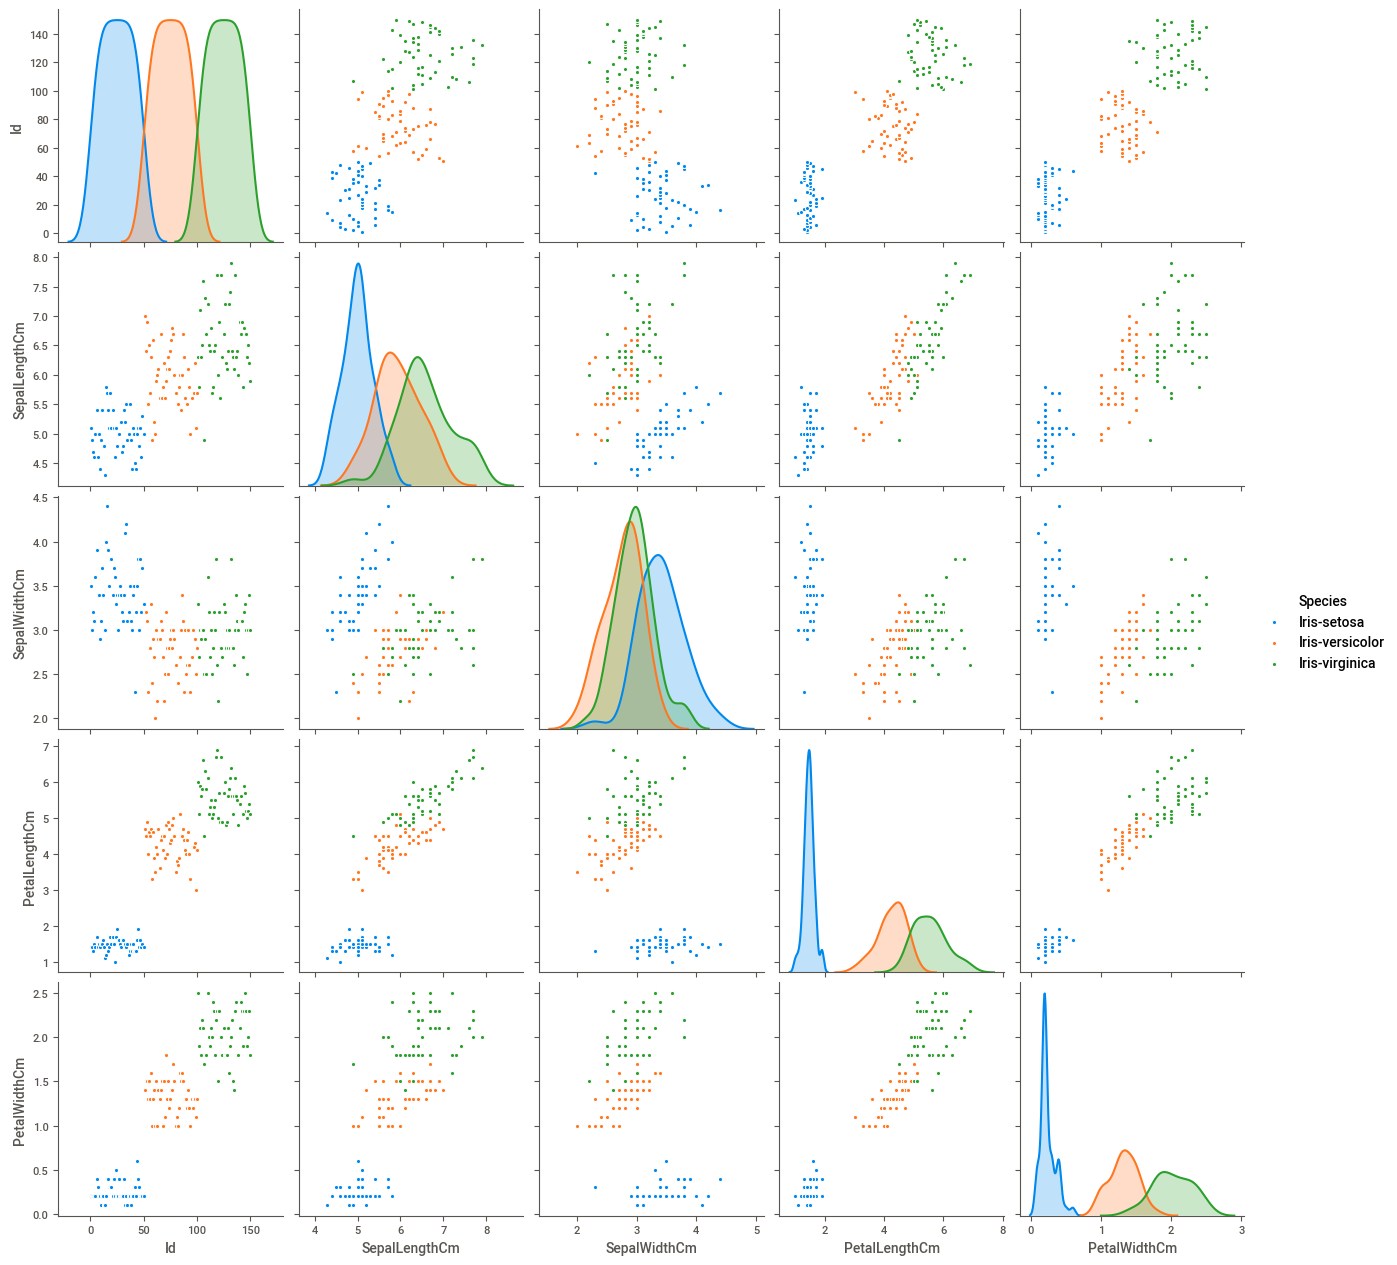

In [7]:
ax = sns.pairplot(df, hue="Species")

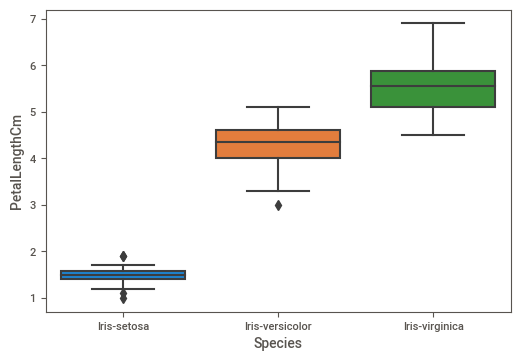

In [8]:
_ = sns.boxplot(x="Species", y="PetalLengthCm", data=df)

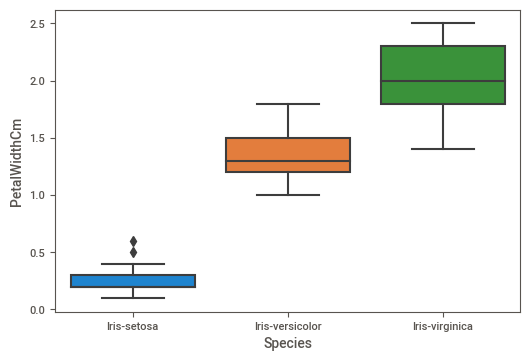

In [9]:
_ = sns.boxplot(x="Species", y="PetalWidthCm", data=df)

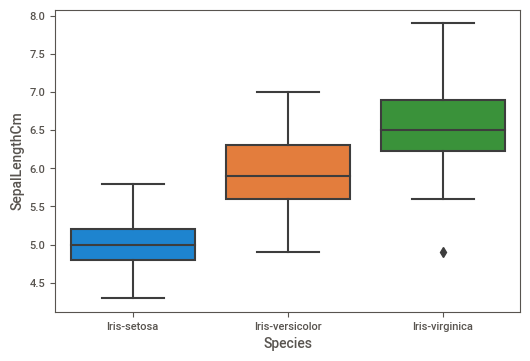

In [10]:
_ = sns.boxplot(x="Species", y="SepalLengthCm", data=df)

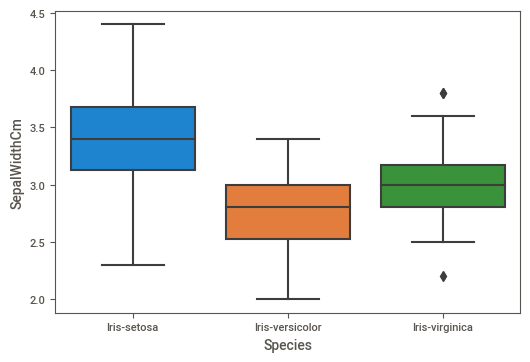

In [11]:
_ = sns.boxplot(x="Species", y="SepalWidthCm", data=df)

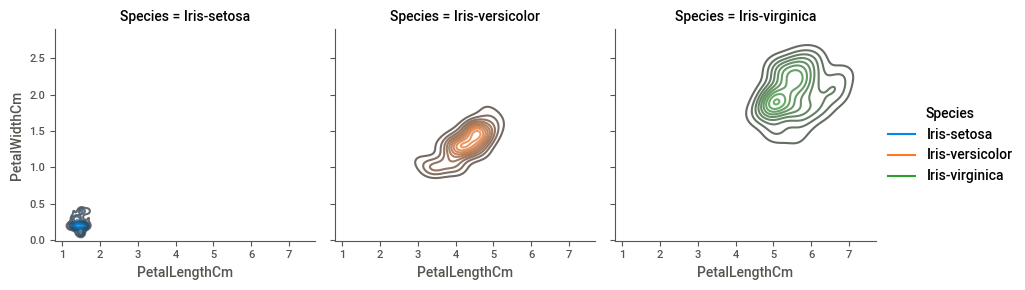

In [12]:
g = sns.FacetGrid(df, col="Species", hue="Species")
_=g.map(sns.kdeplot, "PetalLengthCm", "PetalWidthCm", alpha=.7)
_=g.add_legend()

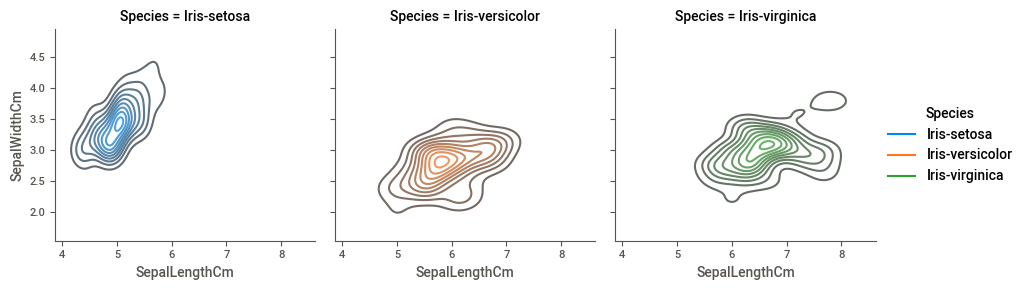

In [13]:
g = sns.FacetGrid(df, col="Species", hue="Species")
_=g.map(sns.kdeplot, "SepalLengthCm", "SepalWidthCm", alpha=.7)
_=g.add_legend()

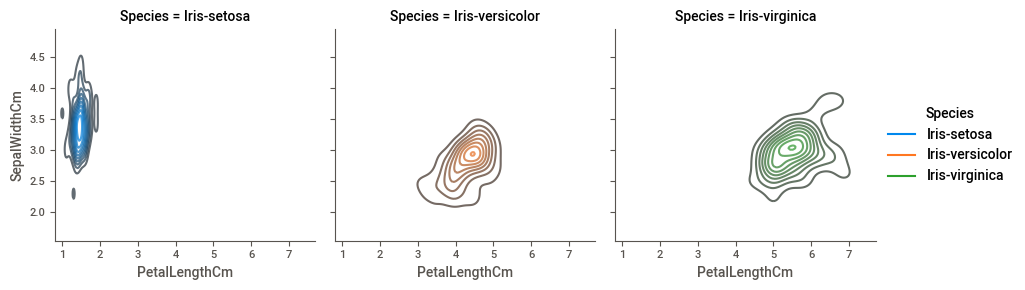

In [14]:
g = sns.FacetGrid(df, col="Species", hue="Species")
_=g.map(sns.kdeplot, "PetalLengthCm", "SepalWidthCm", alpha=.7)
_=g.add_legend()

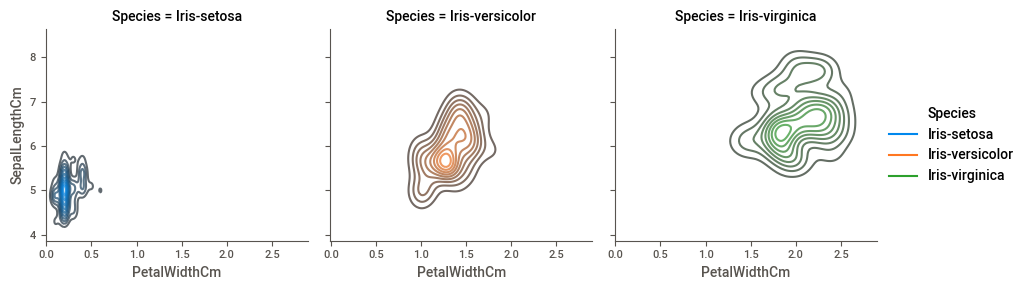

In [15]:
g = sns.FacetGrid(df, col="Species", hue="Species")
_=g.map(sns.kdeplot, "PetalWidthCm", "SepalLengthCm", alpha=.7)
_=g.add_legend()

In [16]:
df.Species.value_counts()

Iris-virginica     50
Iris-setosa        50
Iris-versicolor    50
Name: Species, dtype: int64

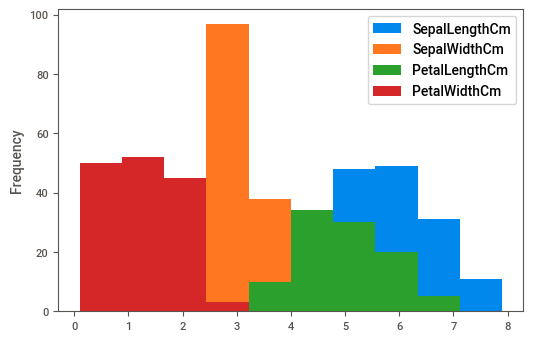

In [17]:
df[df.columns[1:5]].plot(kind='hist')

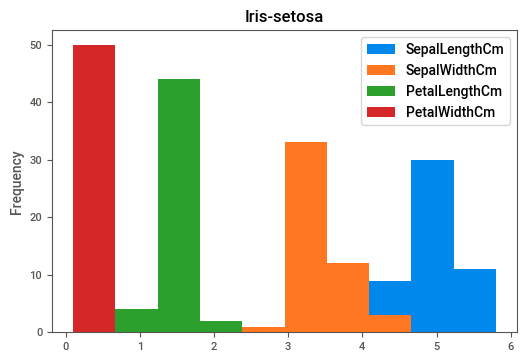

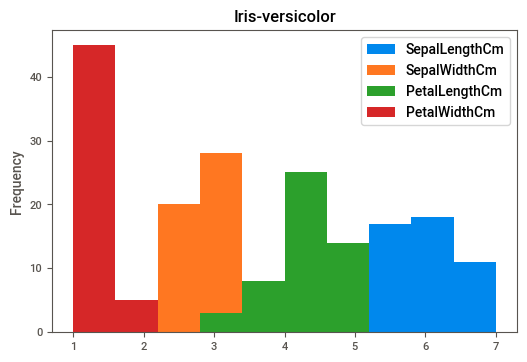

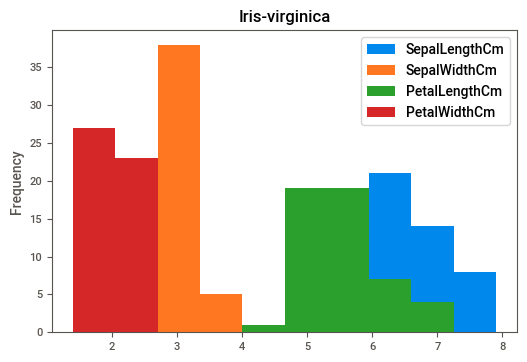

In [18]:
for s in df.Species.unique():
    df.loc[df.Species==s, df.columns[1:5]].plot(kind='hist', title=s)

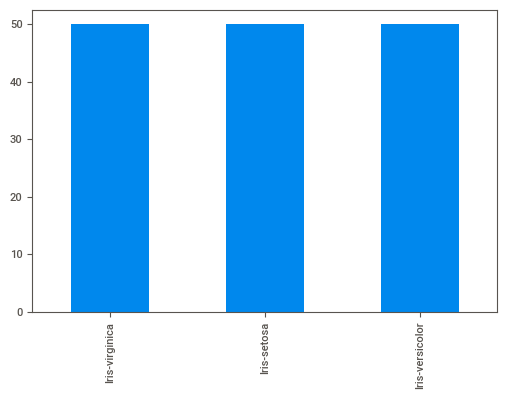

In [19]:
df.Species.value_counts().plot(kind='bar')

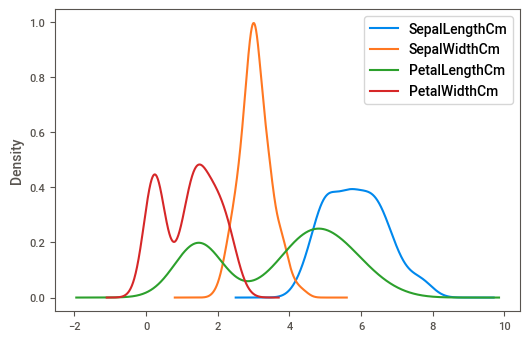

In [20]:
df[df.columns[1:5]].plot(kind='density')

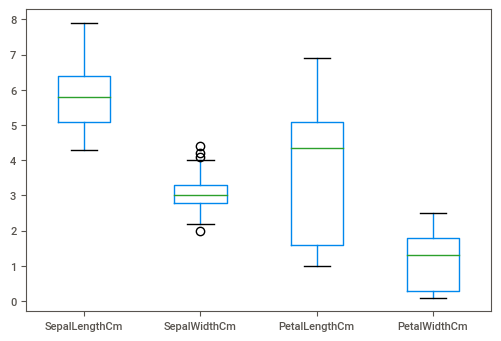

In [21]:
df[df.columns[1:5]].plot(kind='box')

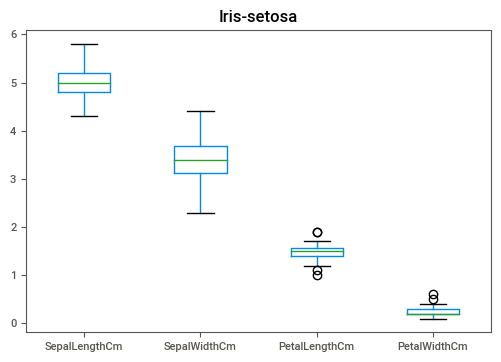

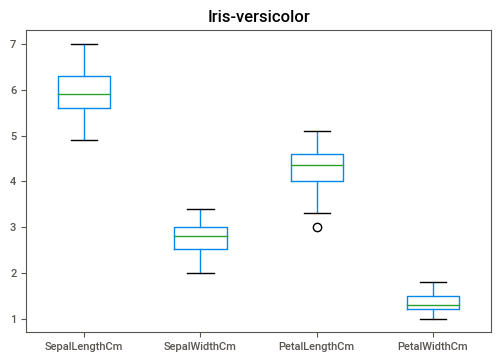

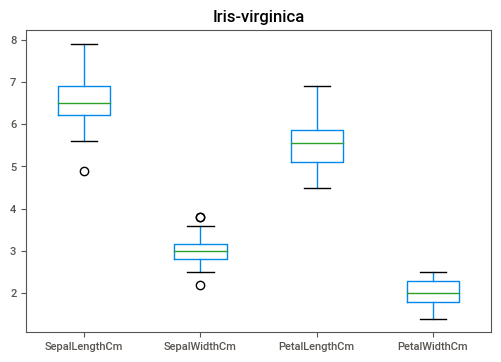

In [22]:
for s in df.Species.unique():
    df.loc[df.Species==s, df.columns[1:5]].plot(kind='box', title=s)

In [23]:
df.Species.replace({'Iris-versicolor' : 3, 'Iris-virginica' : 2, 'Iris-setosa' : 1 }, inplace=True)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1


In [24]:
y = df[['Species']]
X = df.loc[:,df.columns[1:5]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
clf = RandomForestClassifier(max_depth=4, n_estimators=100, random_state=0)
clf.fit(X_train, np.ravel(y_train))
y_pred = clf.predict(X_test)

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
X.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')

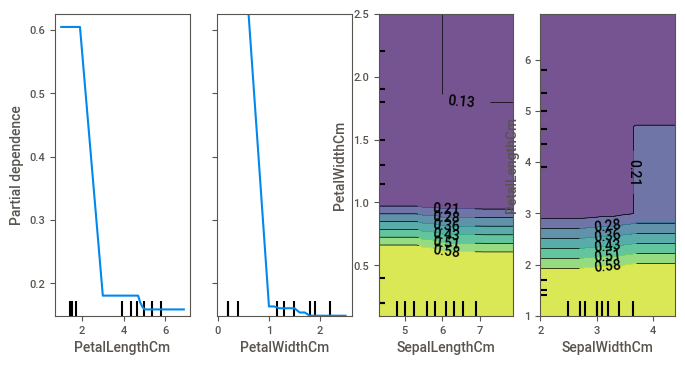

In [28]:
from sklearn.inspection import plot_partial_dependence
features = [2, 3, (0, 3), (1,2)]
plot_partial_dependence(clf, X, features, target=1, n_cols=4) 
# fig.set_figwidth(8)
# fig.set_figheight(15)
# fig.tight_layout()
plt.gcf().set_figwidth(8)

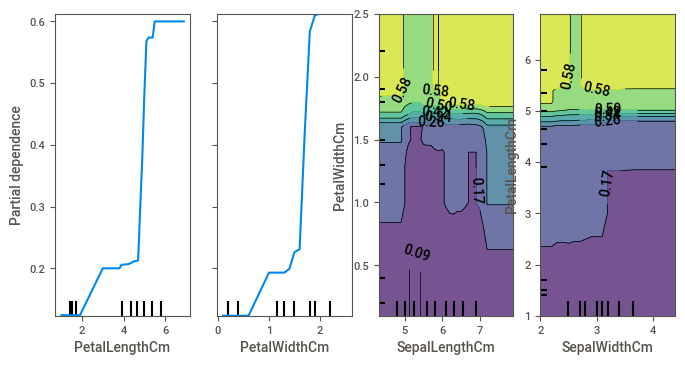

In [29]:
from sklearn.inspection import plot_partial_dependence
features = [2, 3, (0, 3), (1,2)]
plot_partial_dependence(clf, X, features, target=2, n_cols=4) 
# fig.set_figwidth(8)
# fig.set_figheight(15)
# fig.tight_layout()
plt.gcf().set_figwidth(8)

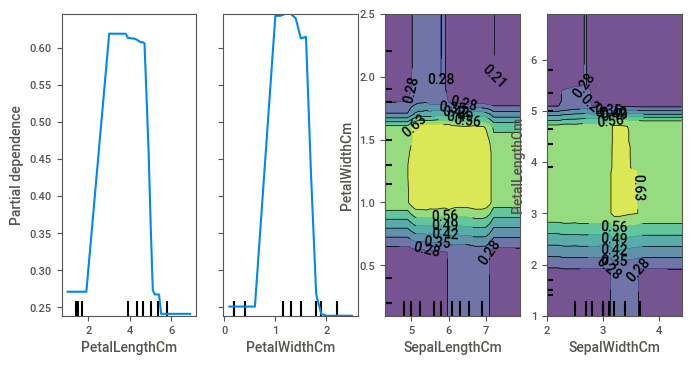

In [30]:
from sklearn.inspection import plot_partial_dependence
features = [2, 3, (0, 3), (1,2)]
plot_partial_dependence(clf, X, features, target=3, n_cols=4) 
# fig.set_figwidth(8)
# fig.set_figheight(15)
# fig.tight_layout()
plt.gcf().set_figwidth(8)

In [31]:
clf.classes_

array([1, 2, 3])

In [32]:
y_test[:5]

,Species
114,2
62,3
33,1
107,2
7,1


In [33]:
import shap

shap.initjs()

explainer = shap.KernelExplainer(clf.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)



In [34]:
# plot the SHAP values for the Setosa output of the first instance
shap.force_plot(explainer.expected_value[0], shap_values[0][0,:], X_test.iloc[0,:])

In [35]:
shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test.iloc[0,:])

In [36]:
shap.force_plot(explainer.expected_value[2], shap_values[2][0,:], X_test.iloc[0,:])

In [37]:
shap_values = explainer.shap_values(X_test)

In [38]:

shap.force_plot(explainer.expected_value[0], shap_values[0], X_test)

In [39]:
shap.force_plot(explainer.expected_value[1], shap_values[1], X_test)

In [40]:
shap.force_plot(explainer.expected_value[2], shap_values[2], X_test)

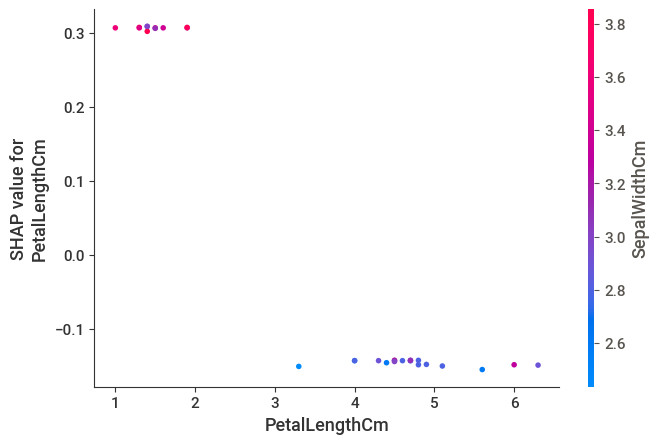

In [41]:
shap.dependence_plot("PetalLengthCm", shap_values[0], X_test)

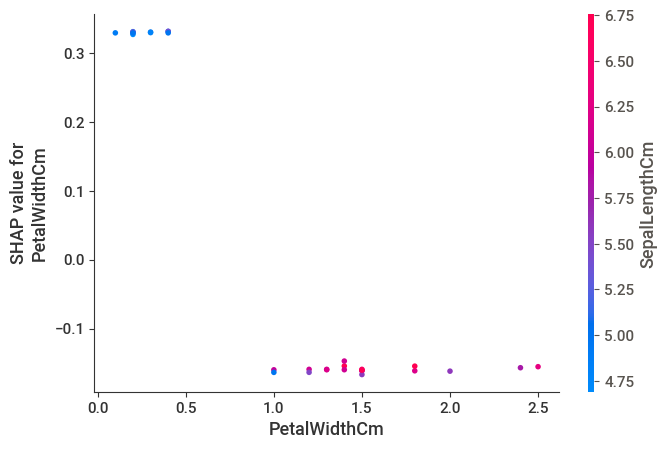

In [42]:
shap.dependence_plot("PetalWidthCm", shap_values[0], X_test)

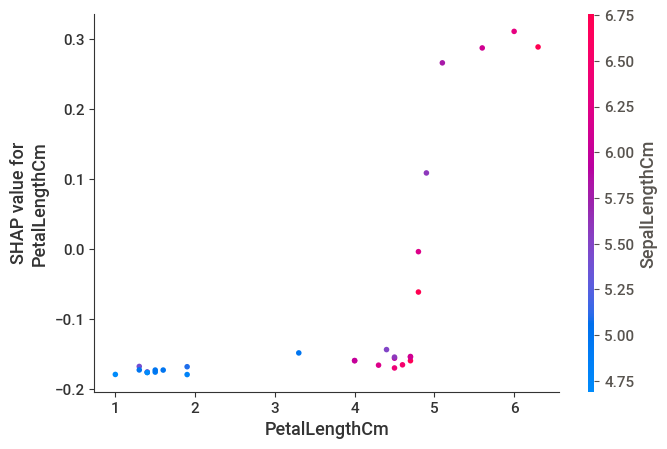

In [43]:
shap.dependence_plot("PetalLengthCm", shap_values[1], X_test)

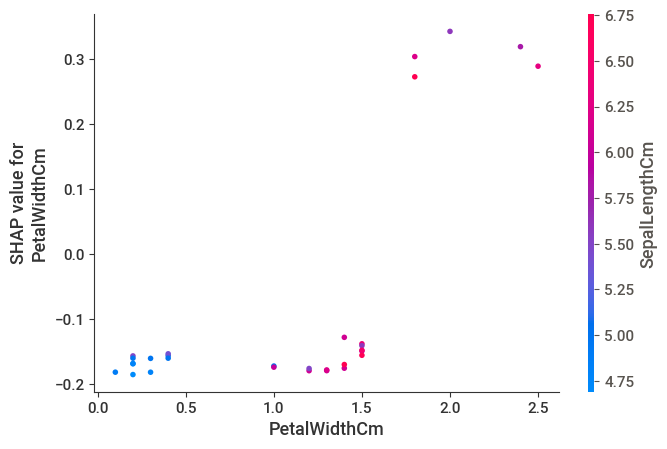

In [44]:
shap.dependence_plot("PetalWidthCm", shap_values[1], X_test)

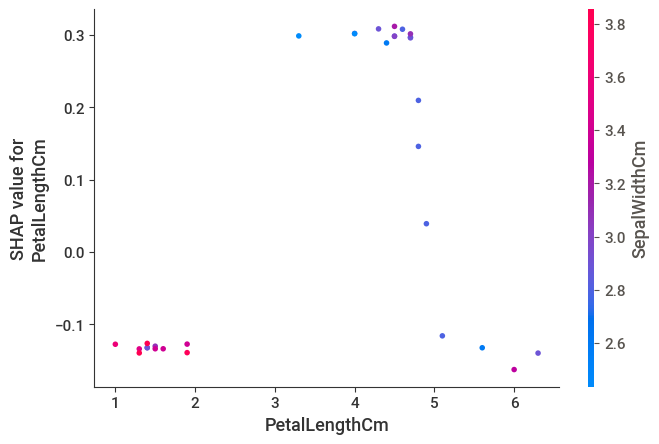

In [45]:
shap.dependence_plot("PetalLengthCm", shap_values[2], X_test)

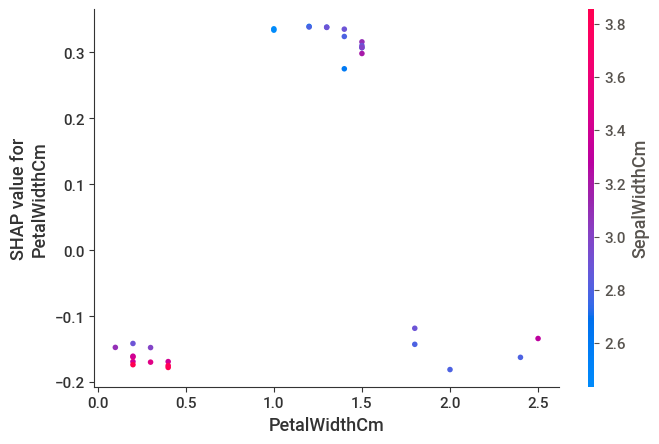

In [46]:
shap.dependence_plot("PetalWidthCm", shap_values[2], X_test)

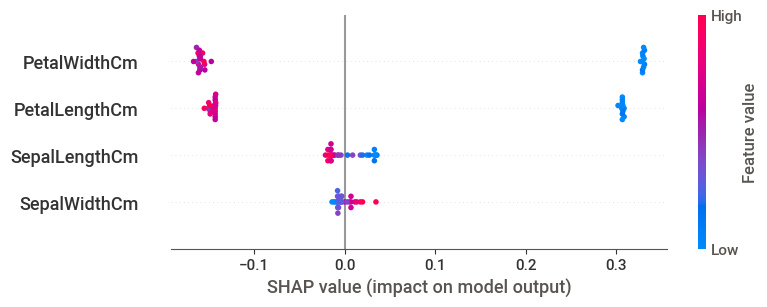

In [47]:
shap.summary_plot(shap_values[0], X_test)

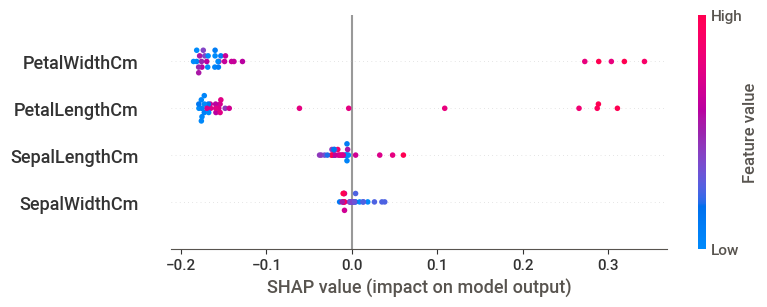

In [48]:
shap.summary_plot(shap_values[1], X_test)

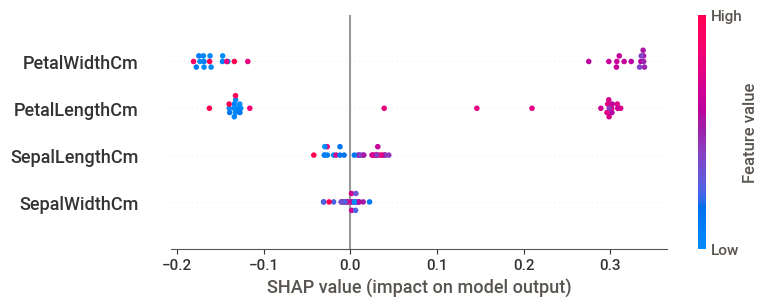

In [49]:
shap.summary_plot(shap_values[2], X_test)

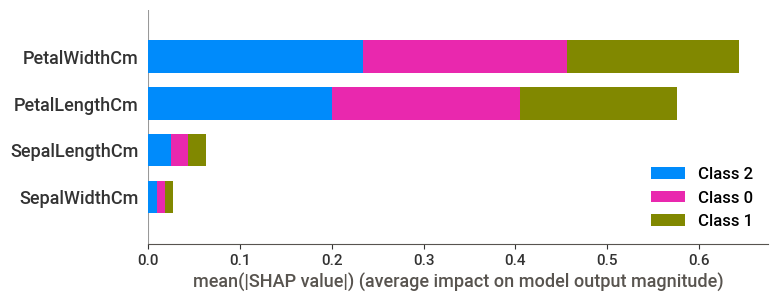

In [50]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [51]:
sgd_clf = SGDClassifier(random_state=0)
sgd_clf.fit(X_train, np.ravel(y_train))
y_pred = sgd_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.58      1.00      0.73        11
           2       0.55      1.00      0.71         6
           3       0.00      0.00      0.00        13

    accuracy                           0.57        30
   macro avg       0.37      0.67      0.48        30
weighted avg       0.32      0.57      0.41        30



Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [52]:
log_clf = LogisticRegression(multi_class='ovr', solver='lbfgs')
log_clf.fit(X_train, np.ravel(y_train))
y_pred = log_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       0.86      1.00      0.92         6
           3       1.00      0.92      0.96        13

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [53]:
xgb_clf = XGBClassifier(random_state=0, n_jobs=-1, learning_rate=0.1, 
                   n_estimators=100, max_depth=3)
xgb_clf.fit(X_train, np.ravel(y_train))
y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [54]:
models = [
#     KNeighborsClassifier(n_neighbors=5,
#                         n_jobs=-1),
    SGDClassifier(random_state=0),
        
#     RandomForestClassifier(random_state=0, n_jobs=-1, 
#                            n_estimators=100, max_depth=3),
     RandomForestClassifier(random_state=0),    
#     XGBClassifier(random_state=0, n_jobs=-1, learning_rate=0.1, 
#                   n_estimators=100, max_depth=3)
    LogisticRegression(random_state=0,multi_class='ovr', solver='lbfgs')
]


In [55]:
S_train, S_test = stacking(models,                   
                           X_train, np.ravel(y_train), X_test,   
                           regression=False, 
     
                           mode='oof_pred_bag', 
       
                           needs_proba=False,
         
                           save_dir=None, 
            
                           metric=accuracy_score, 
    
                           n_folds=4, 
                 
                           stratified=True,
            
                           shuffle=True,  
            
                           random_state=0,    
         
                           verbose=2)

task:         [classification]
n_classes:    [3]
metric:       [accuracy_score]
mode:         [oof_pred_bag]
n_models:     [3]

model  0:     [SGDClassifier]
    fold  0:  [0.66666667]
    fold  1:  [0.76666667]
    fold  2:  [0.93333333]
    fold  3:  [0.83333333]
    ----
    MEAN:     [0.80000000] + [0.09718253]
    FULL:     [0.80000000]

model  1:     [RandomForestClassifier]
    fold  0:  [0.96666667]
    fold  1:  [0.90000000]
    fold  2:  [1.00000000]
    fold  3:  [0.86666667]
    ----
    MEAN:     [0.93333333] + [0.05270463]
    FULL:     [0.93333333]

model  2:     [LogisticRegression]
    fold  0:  [0.93333333]
    fold  1:  [0.90000000]
    fold  2:  [0.96666667]
    fold  3:  [0.90000000]
    ----
    MEAN:     [0.92500000] + [0.02763854]
    FULL:     [0.92500000]



In [56]:
S_train

array([[2, 2, 2],
       [3, 3, 3],
       [1, 1, 1],
       [3, 2, 2],
       [2, 2, 2],
       [3, 3, 3],
       [1, 1, 1],
       [3, 2, 2],
       [3, 3, 3],
       [2, 3, 3],
       [2, 2, 2],
       [1, 1, 1],
       [2, 2, 2],
       [1, 1, 1],
       [1, 1, 1],
       [3, 3, 3],
       [2, 2, 2],
       [2, 2, 2],
       [2, 3, 3],
       [2, 2, 2],
       [3, 3, 3],
       [2, 2, 2],
       [3, 3, 2],
       [2, 3, 3],
       [3, 2, 2],
       [2, 3, 2],
       [2, 3, 3],
       [2, 2, 2],
       [2, 3, 2],
       [3, 2, 2],
       [2, 3, 2],
       [1, 1, 1],
       [2, 2, 2],
       [2, 3, 3],
       [2, 3, 3],
       [3, 3, 3],
       [3, 3, 3],
       [2, 2, 2],
       [1, 1, 1],
       [1, 1, 1],
       [2, 2, 2],
       [3, 3, 3],
       [1, 1, 1],
       [1, 1, 1],
       [2, 3, 2],
       [1, 1, 1],
       [2, 2, 2],
       [3, 3, 3],
       [1, 1, 1],
       [2, 3, 3],
       [2, 2, 2],
       [2, 3, 3],
       [1, 1, 1],
       [2, 2, 2],
       [2, 2, 2],
       [2,

In [57]:
S_train.shape

(120, 3)

In [58]:
S_test

array([[2, 2, 2],
       [3, 3, 3],
       [1, 1, 1],
       [2, 2, 2],
       [1, 1, 1],
       [2, 2, 2],
       [1, 1, 1],
       [2, 3, 2],
       [2, 3, 2],
       [2, 3, 3],
       [2, 2, 2],
       [2, 3, 2],
       [2, 3, 3],
       [2, 3, 3],
       [2, 3, 3],
       [1, 1, 1],
       [2, 3, 3],
       [2, 3, 3],
       [1, 1, 1],
       [1, 1, 1],
       [2, 2, 2],
       [2, 3, 3],
       [1, 1, 1],
       [1, 1, 1],
       [2, 2, 2],
       [1, 1, 1],
       [1, 1, 1],
       [2, 3, 3],
       [3, 3, 3],
       [1, 1, 1]])

In [59]:
S_test.shape

(30, 3)

In [60]:
# model = XGBClassifier(random_state=0, n_jobs=-1, learning_rate=0.1, 
#                       n_estimators=100, max_depth=3)
model = LogisticRegression(multi_class='ovr', solver='lbfgs')    
model = model.fit(S_train, np.ravel(y_train))
y_pred = model.predict(S_test)
print('Final prediction score: [%.8f]' % accuracy_score(y_test.values, y_pred))

Final prediction score: [1.00000000]


In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

